In [19]:
import stim
import numpy as np

from spiderwarp.csscode import CSSCode
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.stim_utils import steane_se_from_stim_state_prep, get_num_measurements, perfect_state_from_code, \
    get_circuit_depth
from spiderwarp.path_cover import CoveredZXGraph
from spiderwarp.path_cover_metrics import metric_spacetime_volume_exact, metric_hardware_qubits_exact, metric_num_paths, \
    metric_depth, LexicographicCost, metric_depth_exact
from spiderwarp.qubit_reuse import build_circuit_dag, apply_logical_qubit_merge_and_compress, dag_to_circuit, \
    inject_qubit_reuse, VolumeOptimizingReuseStrategy, AggressiveDepthAwareStrategy, NoReuseStrategy


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# code_dir, code_name, circ_dir, circ_path = "MQT", "7_1_3", "SAT", "steane/zero_ft_opt_opt"
code_dir, code_name, circ_dir, circ_path = "MQT", "17_1_5", "SAT", "cc_4_8_8_d5/zero_ft_heuristic_opt"
code_dir, code_name, circ_dir, circ_path = "MQT", "17_1_5", "misc", "zero_17_1_5"
# code_dir, code_name, circ_dir, circ_path = "MQT", "15_7_3", "SAT", "hamming/zero_ft_opt_opt"
# code_dir, code_name, circ_dir, circ_path = "MQT", "12_2_4", "SAT", "carbon/zero_ft_opt_opt"
# code_dir, code_name, circ_dir, circ_path = "MQT", "25_1_5", "SAT", "rotated_surface_d5/zero_ft_heuristic_opt"
# code_dir, code_name, circ_dir, circ_path = "MQT", "19_1_5", "SAT", "cc_6_6_6_d5/zero_ft_heuristic_opt"
# code_dir, code_name, circ_dir, circ_path = "MQT", "15_1_3", "SAT", "tetrahedral/zero_ft_opt_opt"
code = CSSCode.load_code(code_dir, code_name)

perfect_state = perfect_state_from_code(code, "X")

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Depth: 17
Width per Timestep: [12, 20, 11, 7, 9, 9, 7, 6, 3, 2, 2, 2, 3, 3, 2, 4, 2]
#Qubits: 26
All trivial syndromes: False


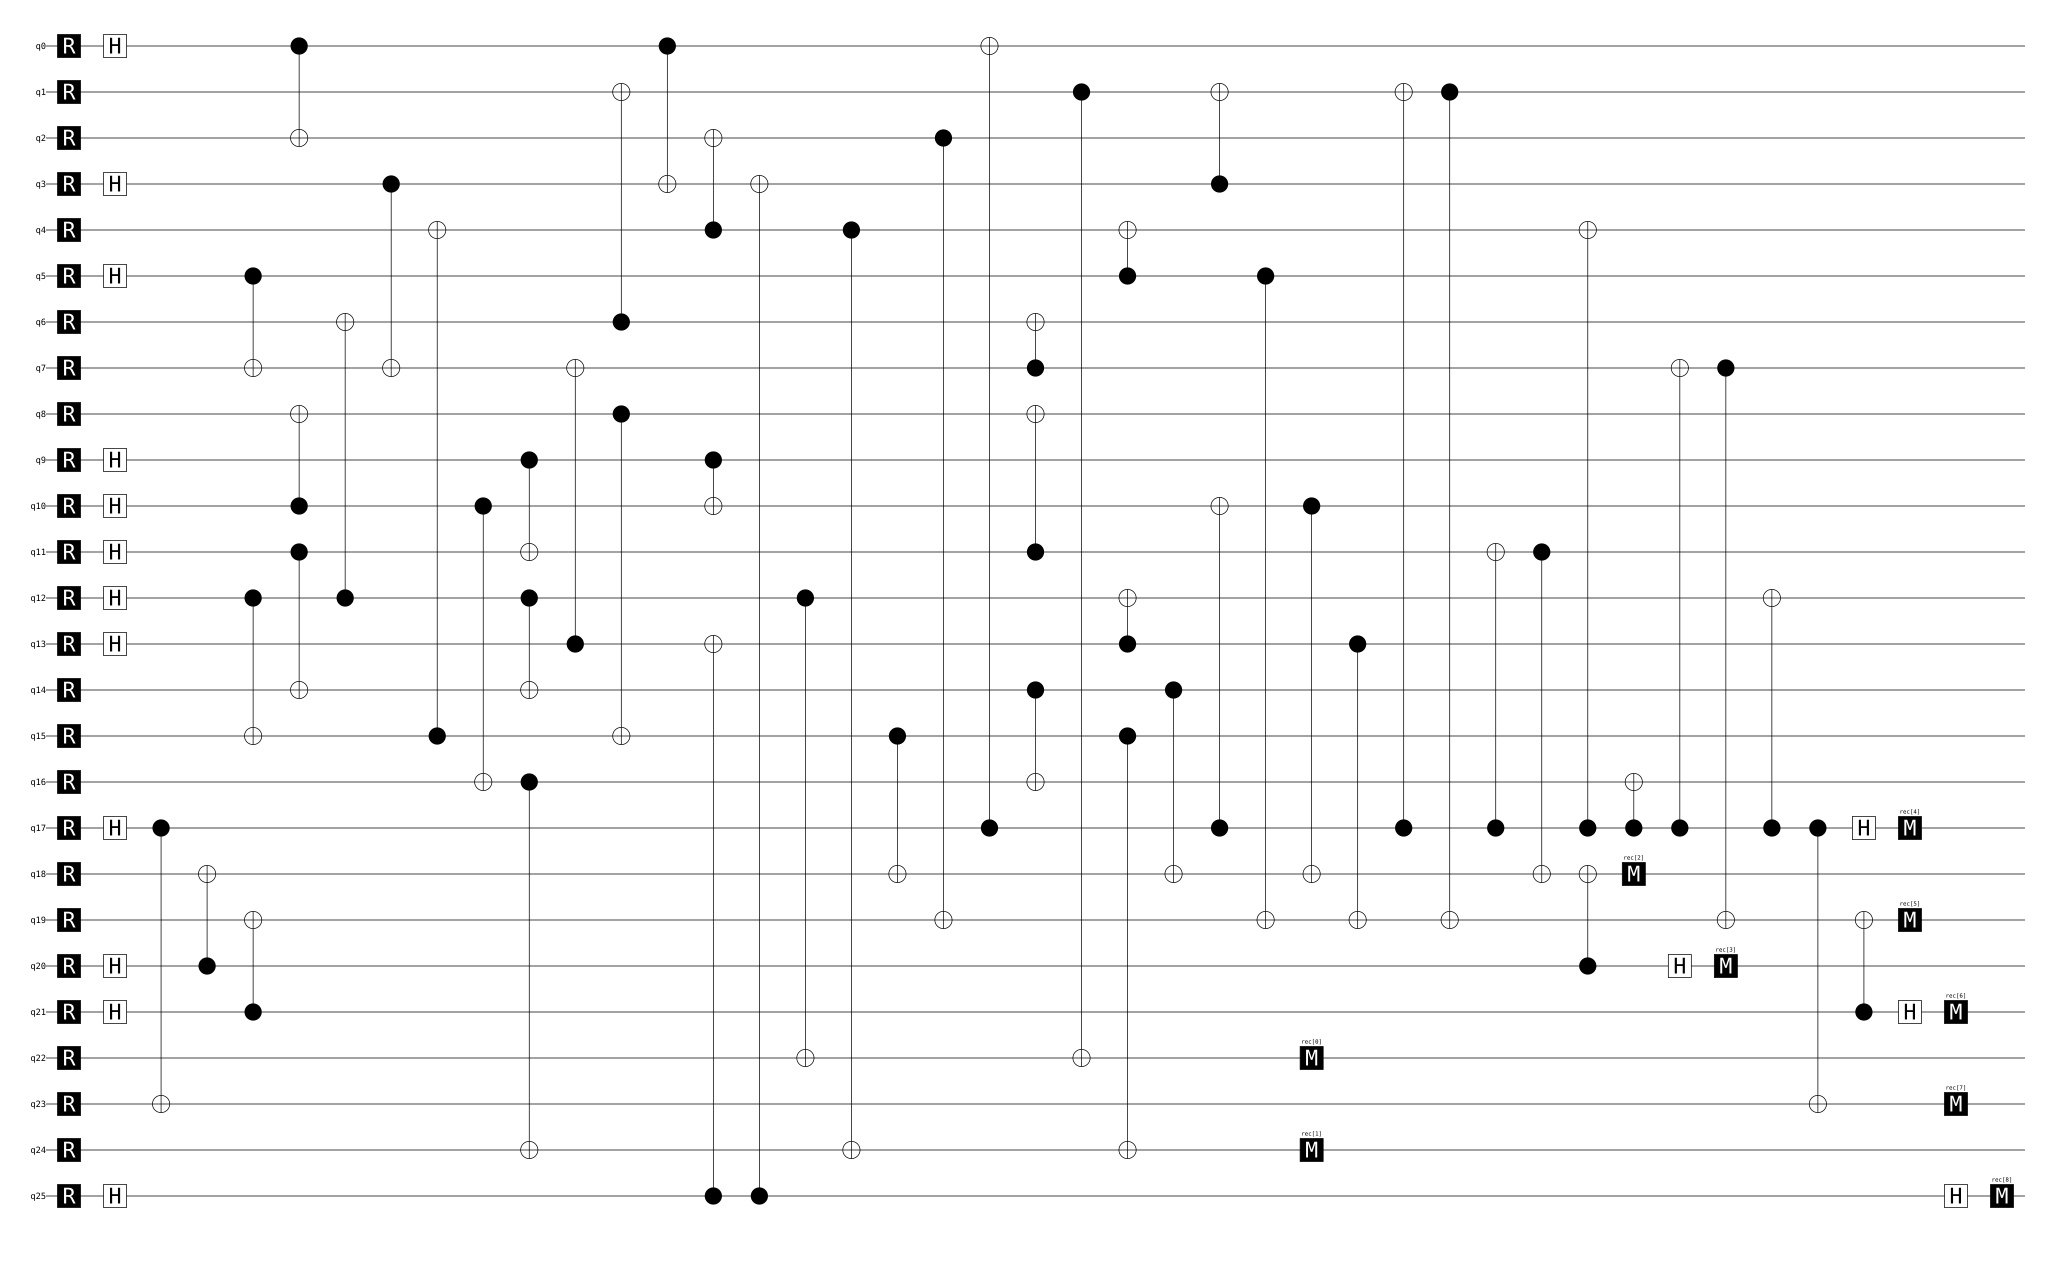

In [15]:
from spiderwarp.stim_utils import get_circuit_width_per_timestep

circuit = load_state_prep_circuit(circ_dir, circ_path)

print("Depth:", get_circuit_depth(circuit))
print("Width per Timestep:", get_circuit_width_per_timestep(circuit))
print("#Qubits:", circuit.num_qubits)
test = circuit.copy()
test.append("M", range(code.n))
print("All trivial syndromes:", np.all((test.compile_sampler().sample(100)[:,-code.n:] @ code.H_x.T % 2) == 0))
circuit.diagram('timeline-svg')

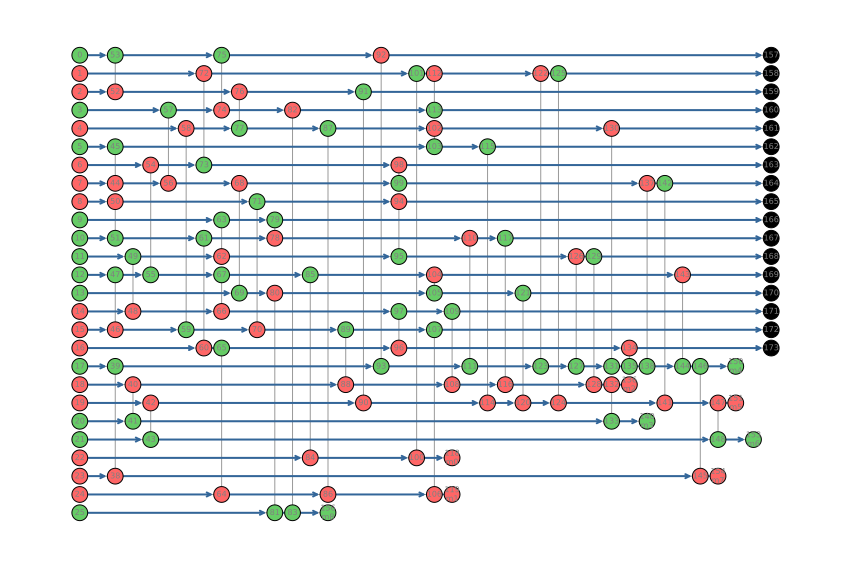

In [25]:
covered = CoveredZXGraph.from_stim(circuit, num_data_qubits=0)
# covered.basic_FE_rewrites()
covered.optimize_path_extremities(max_iterations=10000)
covered.visualize(figsize=(15, 10))

In [21]:
new_circuit, measurement_map = covered.extract_circuit_with_measurement_map()
print("Depth:", get_circuit_depth(new_circuit))
print("Width per Timestep:", get_circuit_width_per_timestep(new_circuit))
print("Number of ancilla qubits necessary:", new_circuit.num_qubits)
test = new_circuit.copy()
test.append("M", range(code.n))
print("All trivial syndromes:", np.all(test.compile_sampler().sample(100)[:,-code.n:] @ code.H_x.T % 2 == 0))
new_circuit.diagram('timeline-svg')

ValueError: No solution found: cycle detected in causal-flow constraints.